In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import precision_score, confusion_matrix,  ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [2]:
iris_df = pd.read_csv("irisdatasets.csv") 
print(iris_df.duplicated().sum()) 
iris_df = iris_df.drop_duplicates(subset=["sepal_length","sepal_width","petal_length","petal_width"])
print(iris_df.duplicated().sum()) 
iris_df.reset_index(drop=True, inplace=True) 
print(iris_df.head())

3
0
   sepal_length  sepal_width  petal_length  petal_width      species
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           4.7          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa


In [3]:
X = iris_df.drop("species", axis=1)
y = iris_df["species"]

print(len(X))
print(len(y))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(len(X_train))
print(len(X_test))

147
147
117
30


In [4]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [5]:
kernels = ["linear", "poly", "rbf", "sigmoid"]
c_values = [0.1 , 1, 10]

results = []

for kernel in kernels:
    for i, c in enumerate(c_values, start=1):
        c_label = f"c{i}"
        model = SVC(kernel=kernel, C=c, gamma=0.5, random_state=42)
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        precision = precision_score(y_test, y_pred, average="macro", zero_division=0)
        results.append({
            "Type of Kernel": kernel.capitalize(),
            "c_label": c_label,
            "C": c,
            "PrecisionResult": round(precision, 4)
        })

df_results = pd.DataFrame(results)
df_results
model.fit

<bound method BaseLibSVM.fit of SVC(C=10, gamma=0.5, kernel='sigmoid', random_state=42)>

In [6]:
result_table = df_results.pivot(index="Type of Kernel", columns="c_label", values="PrecisionResult")
result_table = result_table.reindex(index=["Linear", "Poly", "Rbf", "Sigmoid"])
result_table = result_table[["c1", "c2", "c3"]]
for i, c in enumerate(c_values):
    print(f"c{i+1} = {c}")
result_table

c1 = 0.1
c2 = 1
c3 = 10


c_label,c1,c2,c3
Type of Kernel,,,
Linear,0.9333,1.0000,0.9697
Poly,0.9048,0.9444,0.9333
Rbf,0.9024,0.9333,0.9697
Sigmoid,0.8627,0.8627,0.7708


Best SVM: kernel = linear, C= 1.0, precision= 1.0


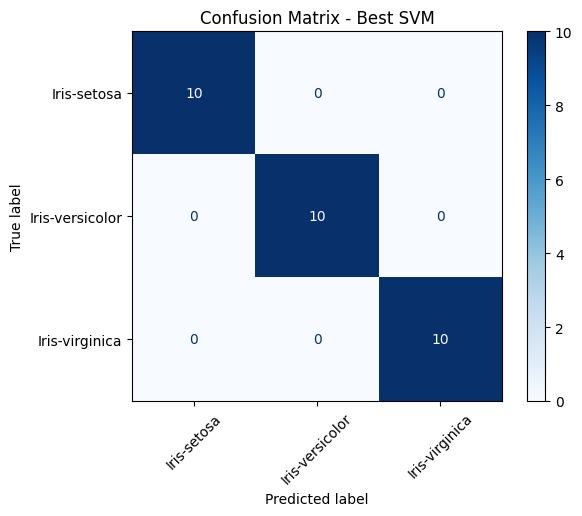

<bound method BaseLibSVM.fit of SVC(C=np.float64(1.0), gamma=0.5, kernel='linear', random_state=42)>

In [7]:
best_row = df_results.sort_values(by="PrecisionResult", ascending=False).iloc[0]
best_kernel = best_row["Type of Kernel"].lower()
best_c = best_row["C"]

best_model = SVC(kernel=best_kernel, C=best_c, gamma=0.5, random_state=42)
best_model.fit(X_train_scaled, y_train)
best_pred = best_model.predict(X_test_scaled)

print(f"Best SVM: kernel = {best_kernel}, C= {best_c}, precision= {best_row['PrecisionResult']}")

# Confusion matrix
labels = sorted(y.unique())
cm = confusion_matrix(y_test, best_pred, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix - Best SVM")
plt.show()
best_model.fit